# Category **1010 & 1020** · Business SCIS (2 deck riêng)

Notebook tổng hợp insight từ 4 EDA notebooks → **2 deck markdown**:
- **1010 — Căn hộ / Chung cư**
- **1020 — Nhà ở**

Cấu trúc mỗi deck: **SITUATION → CHALLENGES → STRATEGIES → IMPACTS**

| Nguồn | Mô tả |
|-------|--------|
| `eda_category_1010_1020_performance.ipynb` | CVR catalog, slices, area bucket |
| `eda_category_1010_1020_behavior_deepdive.ipynb` | Supply, funnel, device, segments |
| `eda_category_1010_1020_clustering.ipynb` | Health segments, cluster profiles |
| `eda_category_1010_1020_cluster_bridge.ipynb` | Event efficiency, session funnel |

**Chạy:** Run All từ Setup. Export: `outputs/category_{1010,1020}_business/`.

In [1]:
%matplotlib inline
import json
import os
from pathlib import Path

import pandas as pd
from IPython.display import Image, Markdown, display

DATA_ROOT = Path.cwd().resolve()
os.environ.setdefault("MPLCONFIGDIR", str(DATA_ROOT / ".mplconfig"))

OUT_1010 = DATA_ROOT / "outputs" / "category_1010_business"
OUT_1020 = DATA_ROOT / "outputs" / "category_1020_business"

for p in (
    DATA_ROOT / "outputs" / "eda_category_1010_1020" / "02_cvr_baseline_adtype.csv",
    DATA_ROOT / "outputs" / "eda_category_behavior" / "1010" / "05_marketing_scorecard.csv",
    DATA_ROOT / "outputs" / "eda_category_1010_1020" / "bridge" / "04_segment_event_efficiency.csv",
):
    if not p.exists():
        raise FileNotFoundError(f"Thiếu CSV nguồn: {p}. Chạy các notebook EDA trước.")

print("OUT 1010 =", OUT_1010)
print("OUT 1020 =", OUT_1020)

OUT 1010 = /Users/dothinh_3112/Downloads/Datathon_Data/outputs/category_1010_business
OUT 1020 = /Users/dothinh_3112/Downloads/Datathon_Data/outputs/category_1020_business


In [2]:
# Build cả 2 deck: charts + markdown + manifest + impact CSV
import build_category_1010_1020_business_scis as b

b.main()

[1010] wrote /Users/dothinh_3112/Downloads/Datathon_Data/outputs/category_1010_business/category_1010_business_scis.md (10 charts)
[1020] wrote /Users/dothinh_3112/Downloads/Datathon_Data/outputs/category_1020_business/category_1020_business_scis.md (10 charts)


# Preview — 1010 — Căn hộ / Chung cư

## SITUATION

- **611.823 listings**, **74.3% let** — thị trường cho thuê căn hộ; sell 25.7%

- **154.310 login users** (sample); cấu trúc **project × bedrooms (41% có project_id)**

- **TP.HCM ~74.1%** supply — chiến lược theo thành phố, không nationwide generic

- Catalog CVR: let **18.83%**, sell **23.00%** — sell outperform let (+4.2pp)

- Snapshot let: contact-day **11.07%**; listing age ~52 ngày

### Charts — SITUATION

**01_supply_adtype.png**

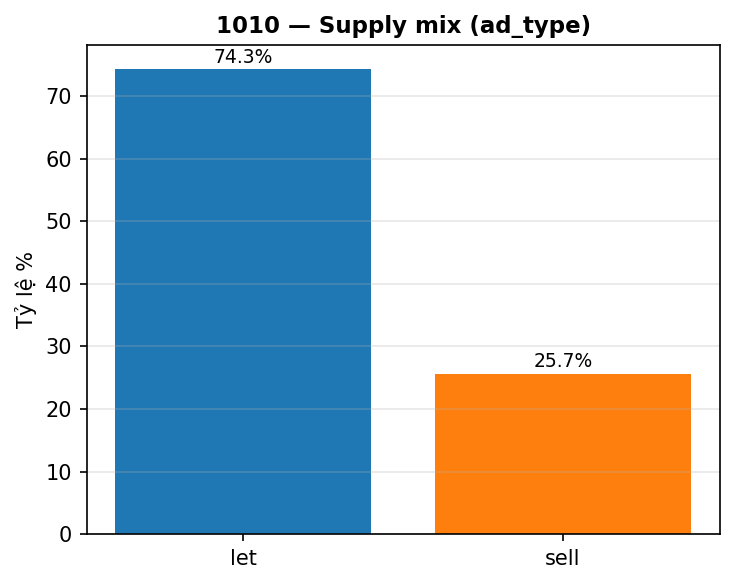

**02_cvr_baseline_adtype.png**

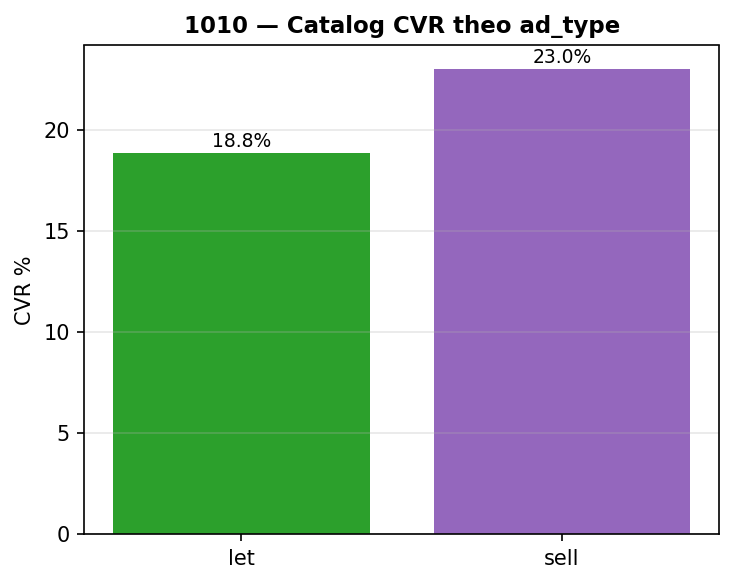

**03_hcm_concentration.png**

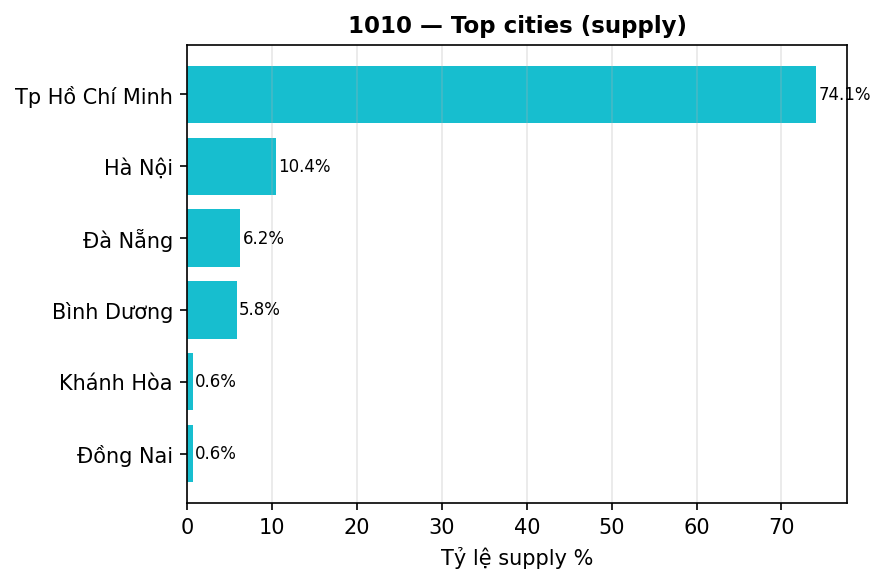

## CHALLENGES

- Funnel login: chỉ **7.78% session** có explicit contact; **50.6% events** là `other_interaction` (94% ad_view)

- **High-intent users 7.68%**; broker/spam **9.58%**

- **~2.328 listings HQ underexposed** (304% contact/pageview, exposure=2) vs **~2.092 oversaturated** (61%, exposure=8)

- Weak pocket: **1-bed let ~18%** CVR trên **~289.540 listings** — volume lớn, conversion thấp

- Catalog CVR bị méo bởi **~85% tin pre-EDA window** — filter in-window cho quyết định product

### Charts — CHALLENGES

**04_session_funnel_gap.png**

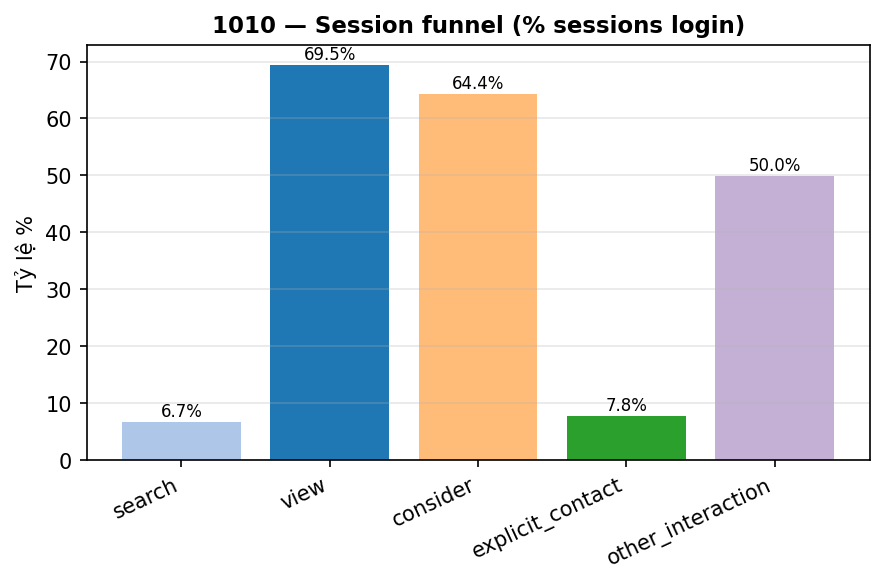

**05_event_layer_mix.png**

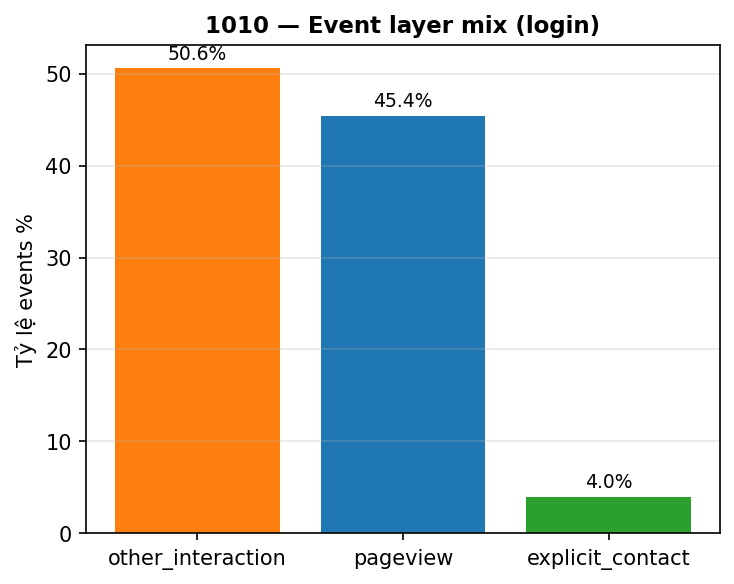

**06_health_segment_efficiency.png**

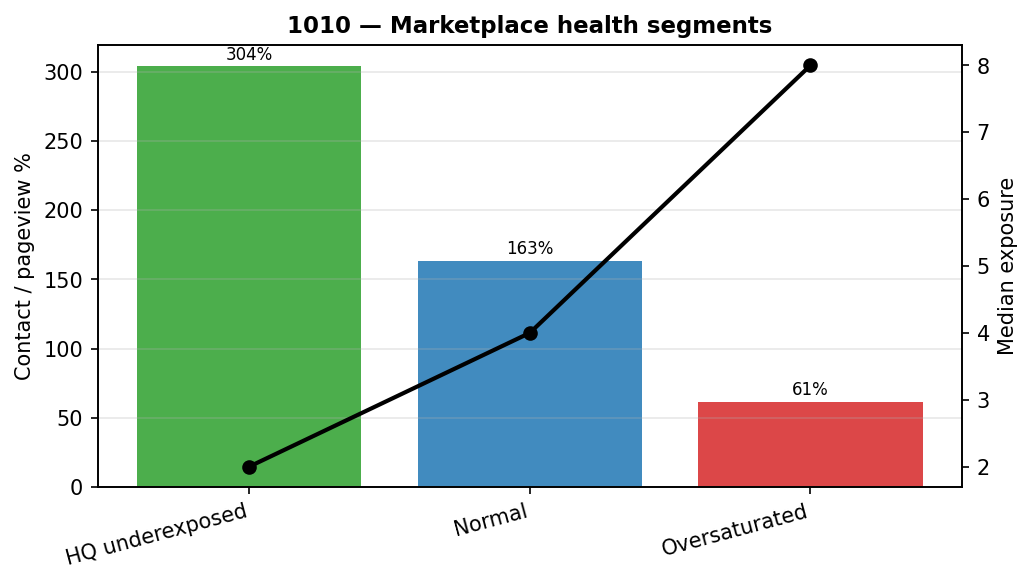

## STRATEGIES

- **Boost 2.328 HQ underexposed** — recsys rank / feed diversity (`10_health_ranked_underexposed_1010.csv`)

- **Demote 2.092 oversaturated** — cap impression share (exposure median 8)

- Chat-first CTA — 30% explicit là contact_chat

- Desktop + iOS (40% + 33%) — UX cross-device cho thuê căn hộ

- **Night-active micro-segment** (~500 users, 99% night) — push/notification theo giờ

- **Listing quality:** ưu tiên 3–4+ PN, project-linked 2-bed sell; completeness furnishing

### Charts — STRATEGIES

**07_contact_channel_mix.png**

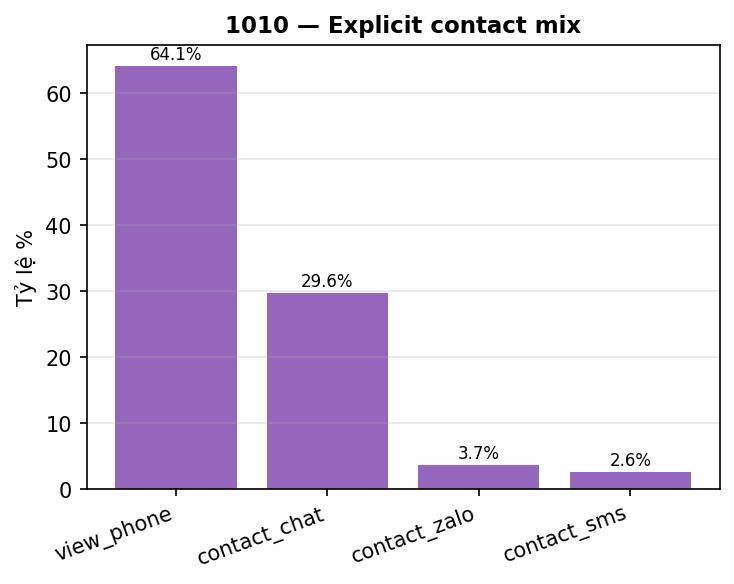

**08_device_mix.png**

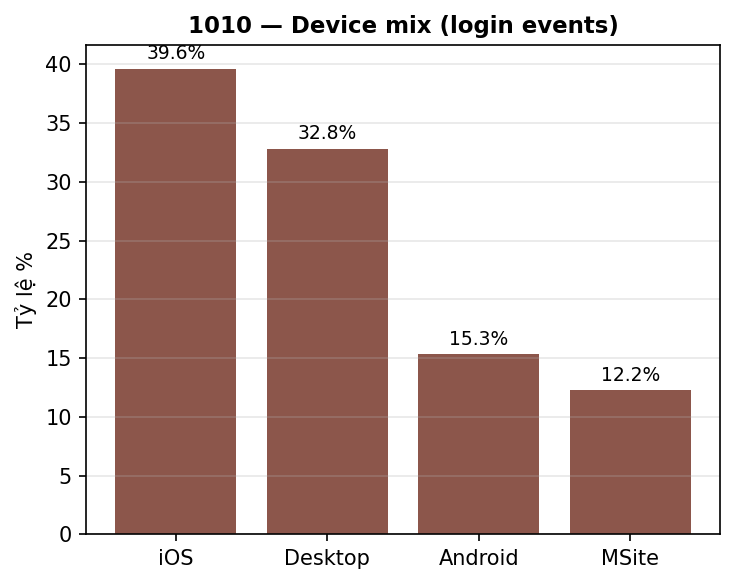

**09_session_archetypes.png**

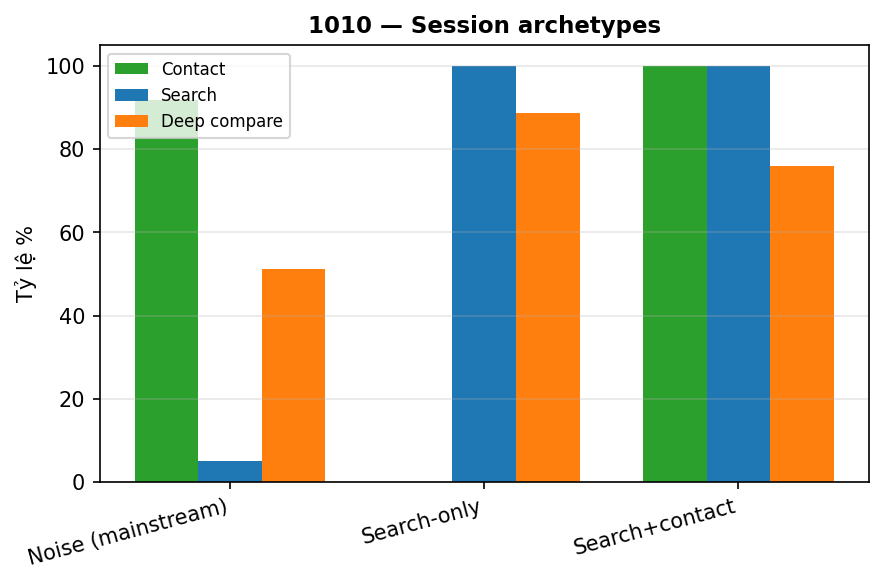

## IMPACTS

- Boost underexposed: **2.328 listings**, exposure 2→4 → ước tính **+39.456 contact events**

- Session explicit **+1pp** (7.78→8.78%) → **+3.705 sessions** có contact (trong sample login)

- Demote oversaturated: tiết kiệm **~68.408 impression-equiv** trên 2.092 tin exposure cao

- Cải thiện 1-bed let ~18% **18.0→20.0%** → **~5.791 listings** thêm contact

### Charts — IMPACTS

**10_impact_whatif.png**

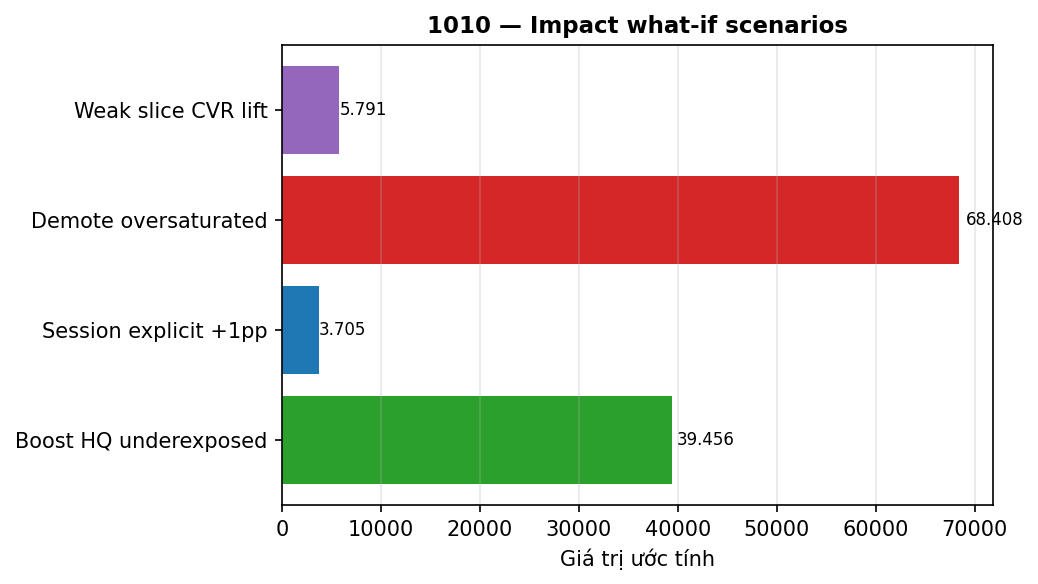

In [3]:
import build_category_1010_1020_business_scis as b

SECTION_CHARTS = b.SECTION_CHARTS

def preview_deck(cat: int) -> None:
    out = DATA_ROOT / "outputs" / f"category_{cat}_business"
    manifest = json.loads((out / "manifest.json").read_text(encoding="utf-8"))
    display(Markdown(f"# Preview — {manifest['label']}"))
    for sec, bullets in manifest["sections"].items():
        display(Markdown(f"## {sec}"))
        for line in bullets:
            display(Markdown(f"- {line}"))
        display(Markdown(f"### Charts — {sec}"))
        for fname in SECTION_CHARTS[sec]:
            p = out / "charts" / fname
            if p.exists():
                display(Markdown(f"**{fname}**"))
                display(Image(filename=str(p)))

preview_deck(1010)

# Preview — 1020 — Nhà ở

## SITUATION

- **1.507.864 listings**, **71.8% sell** — thị trường bán nhà; let 28.2%

- **269.723 login users** (sample); house_type 100%, floors 61%, width 76%

- **TP.HCM ~70.0%** supply — tập trung micro-market HCMC

- Catalog CVR: let **20.45%**, sell **19.32%** — let hơn sell (+1.1pp), **ngược 1010**

- Snapshot: let contact-day **18.97%** (mạnh); sell **8.55%** trên volume lớn

### Charts — SITUATION

**01_supply_adtype.png**

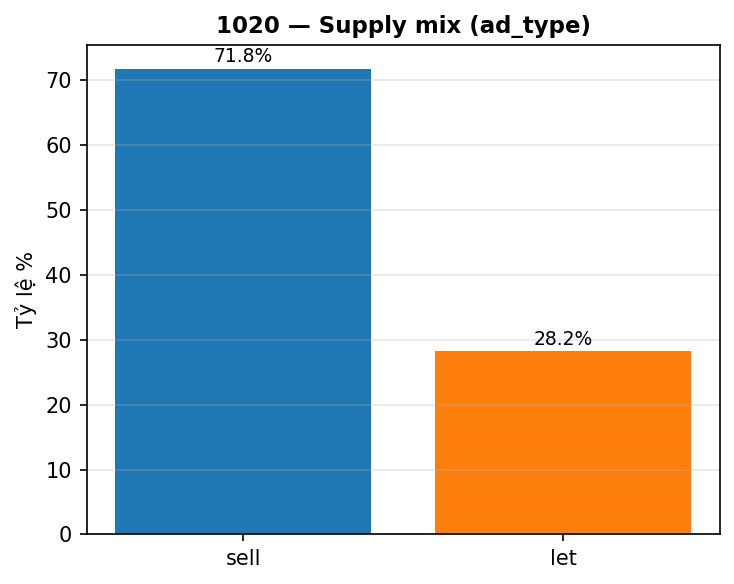

**02_cvr_baseline_adtype.png**

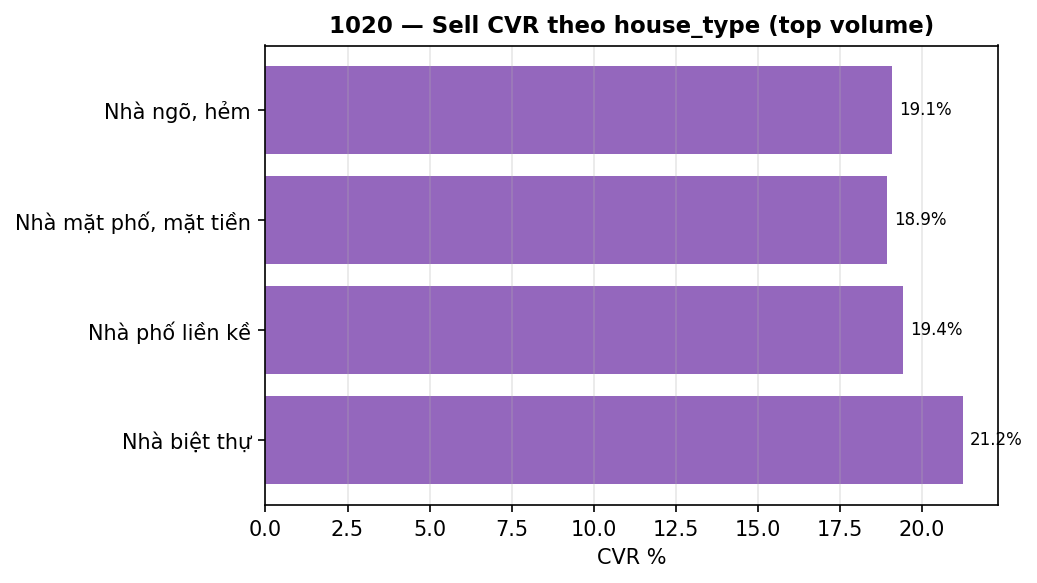

**03_hcm_concentration.png**

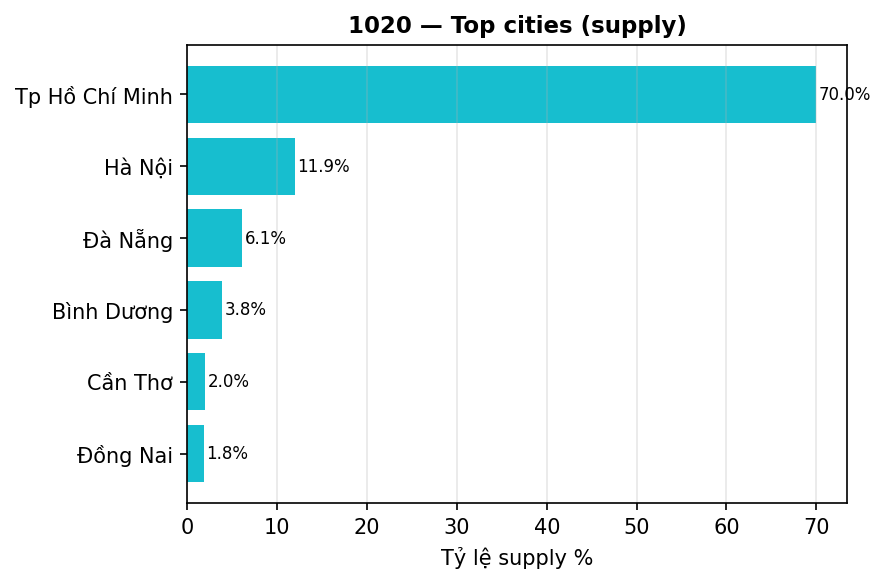

## CHALLENGES

- Funnel login: chỉ **8.38% session** có explicit contact; **50.8% events** là `other_interaction` (96% ad_view)

- **High-intent users 5.98%**; broker/spam **12.38%**

- **~6.187 listings HQ underexposed** (271% contact/pageview, exposure=2) vs **~4.295 oversaturated** (58%, exposure=13)

- Weak pocket: **sell 30–50m² CVR 17.5%** trên **~310.484 listings**; let mặt phố ~15%

- **Bulk seller cluster** (~102 listings/seller, 0.29 PV/listing) — spam/cold supply risk

### Charts — CHALLENGES

**04_session_funnel_gap.png**

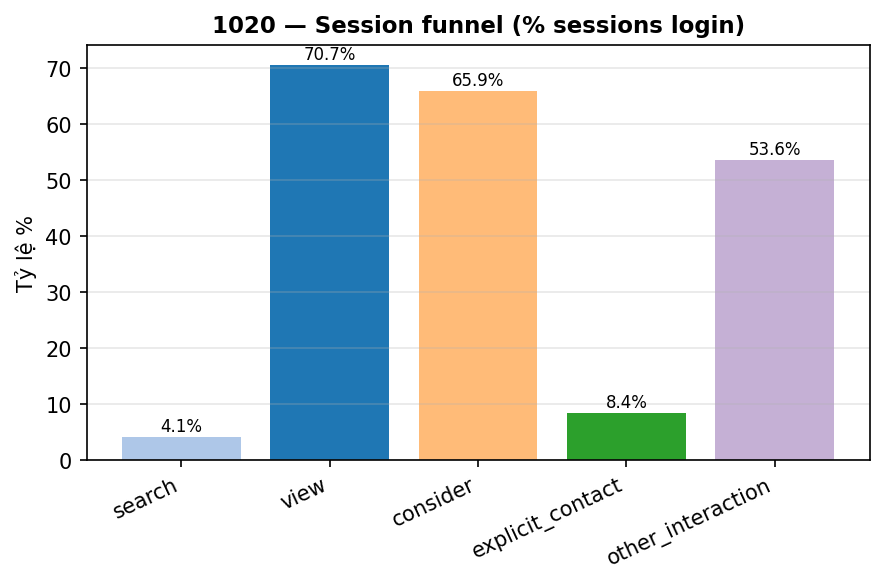

**05_event_layer_mix.png**

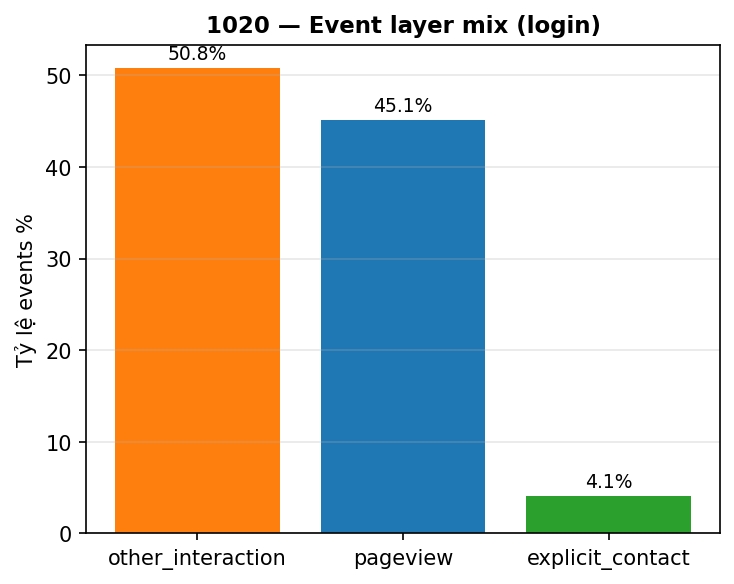

**06_health_segment_efficiency.png**

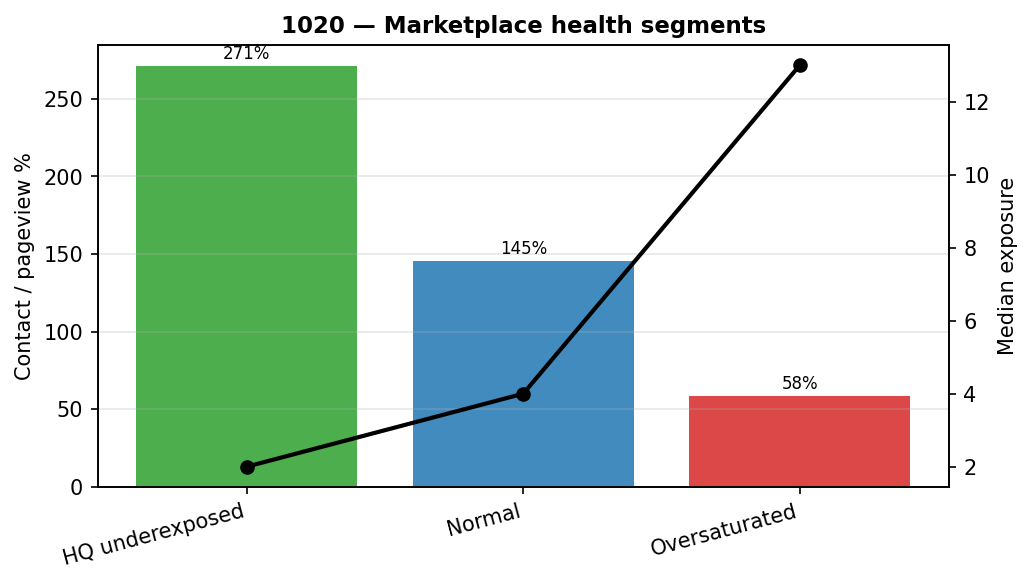

## STRATEGIES

- **Boost 6.187 HQ underexposed** — recsys rank / feed diversity (`10_health_ranked_underexposed_1020.csv`)

- **Demote 4.295 oversaturated** — cap impression share (exposure median 13)

- Phone-first CTA — 76% explicit là view_phone

- Android 26% — mobile-first cho Nhà ở

- **Deep-compare UX** — 60.2% session noise có deep_compare (house buyer journey dài)

- **Listing completeness:** house_type + floors + legal + width; ưu tiên sell HCMC (4.853 HQ underexposed sell)

### Charts — STRATEGIES

**07_contact_channel_mix.png**

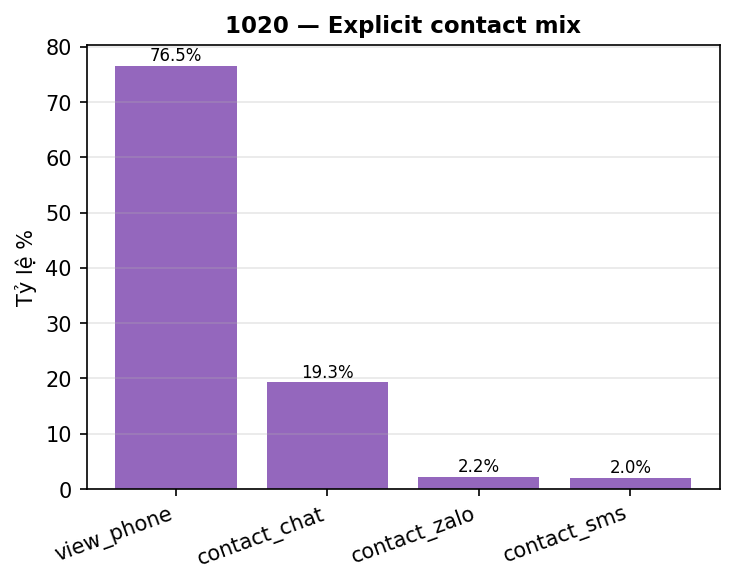

**08_device_mix.png**

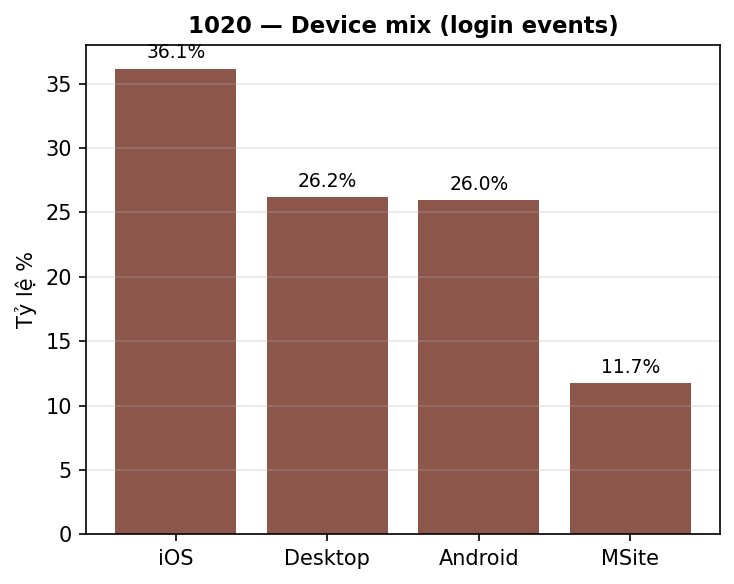

**09_session_archetypes.png**

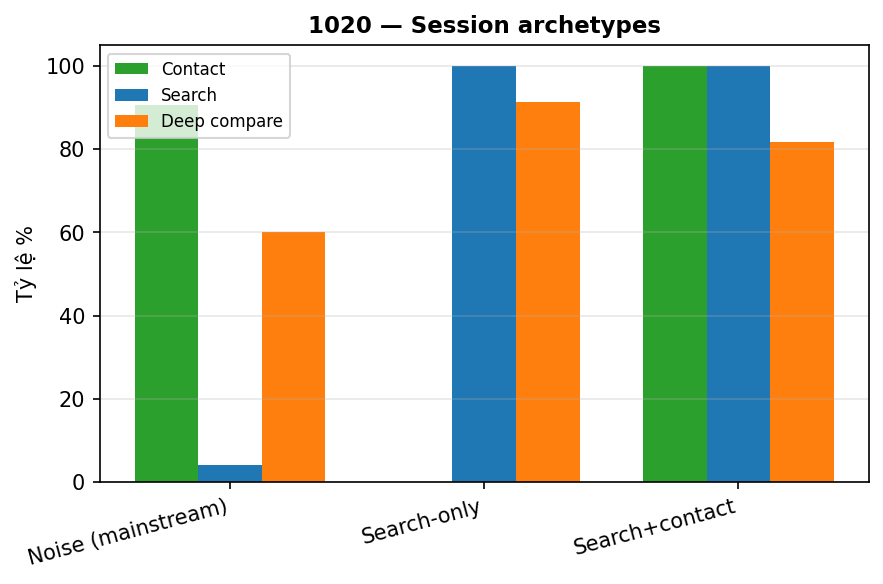

## IMPACTS

- Boost underexposed: **6.187 listings**, exposure 2→4 → ước tính **+92.820 contact events**

- Session explicit **+1pp** (8.38→9.38%) → **+9.721 sessions** có contact (trong sample login)

- Demote oversaturated: tiết kiệm **~322.308 impression-equiv** trên 4.295 tin exposure cao

- Cải thiện sell 30–50m² CVR 17.5% **17.5→19.5%** → **~6.210 listings** thêm contact

### Charts — IMPACTS

**10_impact_whatif.png**

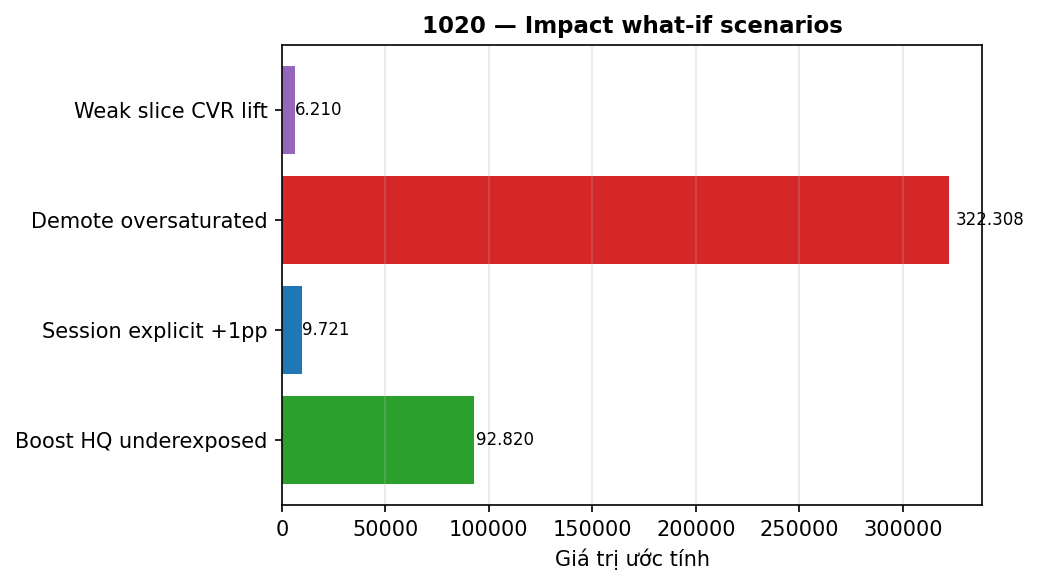

In [4]:
preview_deck(1020)

In [5]:
# Impact what-if — bảng số hóa IMPACTS
for cat, out in [(1010, OUT_1010), (1020, OUT_1020)]:
    impact = pd.read_csv(out / "csv" / "impact_scenarios.csv")
    display(Markdown(f"### Impact scenarios — category {cat}"))
    display(impact)

### Impact scenarios — category 1010

,scenario,value,unit
0,Boost HQ underexposed,39455.764387,contact events
1,Session explicit +1pp,3704.600000,sessions w/ contact
2,Demote oversaturated,68408.400000,impression-equiv saved
3,Weak slice CVR lift,5790.800000,listings w/ contact


### Impact scenarios — category 1020

,scenario,value,unit
0,Boost HQ underexposed,92820.476781,contact events
1,Session explicit +1pp,9720.700000,sessions w/ contact
2,Demote oversaturated,322307.537500,impression-equiv saved
3,Weak slice CVR lift,6209.680000,listings w/ contact


In [6]:
# Markdown deck paths
for cat in (1010, 1020):
    md_path = DATA_ROOT / "outputs" / f"category_{cat}_business" / f"category_{cat}_business_scis.md"
    display(Markdown(f"**Deck {cat}:** `{md_path}`"))
    print(md_path.read_text(encoding="utf-8")[:900], "...\n")

**Deck 1010:** `/Users/dothinh_3112/Downloads/Datathon_Data/outputs/category_1010_business/category_1010_business_scis.md`

# Business insights — 1010 — Căn hộ / Chung cư

> Nguồn: `eda_category_1010_1020_performance`, `behavior_deepdive`, `clustering`, `cluster_bridge` + CSV exports.

## SITUATION

- **611.823 listings**, **74.3% let** — thị trường cho thuê căn hộ; sell 25.7%
- **154.310 login users** (sample); cấu trúc **project × bedrooms (41% có project_id)**
- **TP.HCM ~74.1%** supply — chiến lược theo thành phố, không nationwide generic
- Catalog CVR: let **18.83%**, sell **23.00%** — sell outperform let (+4.2pp)
- Snapshot let: contact-day **11.07%**; listing age ~52 ngày

![SITUATION — 01_supply_adtype.png](charts/01_supply_adtype.png)

![SITUATION — 02_cvr_baseline_adtype.png](charts/02_cvr_baseline_adtype.png)

![SITUATION — 03_hcm_concentration.png](charts/03_hcm_concentration.png)

## CHALLENGES

- Funnel login: chỉ **7.78% session** có explicit contact; **50.6% events** là `other_interaction` (94 ...



**Deck 1020:** `/Users/dothinh_3112/Downloads/Datathon_Data/outputs/category_1020_business/category_1020_business_scis.md`

# Business insights — 1020 — Nhà ở

> Nguồn: `eda_category_1010_1020_performance`, `behavior_deepdive`, `clustering`, `cluster_bridge` + CSV exports.

## SITUATION

- **1.507.864 listings**, **71.8% sell** — thị trường bán nhà; let 28.2%
- **269.723 login users** (sample); house_type 100%, floors 61%, width 76%
- **TP.HCM ~70.0%** supply — tập trung micro-market HCMC
- Catalog CVR: let **20.45%**, sell **19.32%** — let hơn sell (+1.1pp), **ngược 1010**
- Snapshot: let contact-day **18.97%** (mạnh); sell **8.55%** trên volume lớn

![SITUATION — 01_supply_adtype.png](charts/01_supply_adtype.png)

![SITUATION — 02_cvr_baseline_adtype.png](charts/02_cvr_baseline_adtype.png)

![SITUATION — 03_hcm_concentration.png](charts/03_hcm_concentration.png)

## CHALLENGES

- Funnel login: chỉ **8.38% session** có explicit contact; **50.8% events** là `other_interaction` (96% ad_view)
- **High-intent us ...



In [ ]:
import build_category_1010_1020_story as story

story.main()
STORY = DATA_ROOT / "outputs" / "category_1010_1020_story" / "STORY.md"
display(Markdown(f"Data story: `{STORY}`"))
print(STORY.read_text(encoding="utf-8")[:1500], "\n...")